In [1]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

os.makedirs("results", exist_ok=True)
print("✅ Imports ready")

✅ Imports ready


In [2]:
class WeatherModel:
    """
    Simulates physical weather forces acting on the drone.

    3 difficulty levels:
      0 = Calm  : wind 0-2 m/s,  rain 0-5 mm/h,  turbulence std=0.1
      1 = Windy : wind 0-8 m/s,  rain 0-25 mm/h, turbulence std=0.5
      2 = Storm : wind 0-15 m/s, rain 0-50 mm/h, turbulence std=1.5

    Returns force vector [fx, fy, fz] in Newtons.
    """

    LEVELS = {
        0: {"name": "Calm",  "wind": 2.0,  "rain": 5.0,  "turb": 0.1},
        1: {"name": "Windy", "wind": 8.0,  "rain": 25.0, "turb": 0.5},
        2: {"name": "Storm", "wind": 15.0, "rain": 50.0, "turb": 1.5},
    }

    def __init__(self, difficulty=0):
        self.set_difficulty(difficulty)

    def set_difficulty(self, level):
        self.difficulty = level
        cfg = self.LEVELS[level]
        self.wind_max = cfg["wind"]
        self.rain_max = cfg["rain"]
        self.turb_std = cfg["turb"]
        self.name     = cfg["name"]

    def get_forces(self):
        """Returns [fx, fy, fz] disturbance force vector in Newtons"""
        # Wind: random speed and direction
        wind_speed = np.random.uniform(0, self.wind_max)
        wind_dir   = np.random.uniform(0, 2 * np.pi)
        fx = wind_speed * np.cos(wind_dir)
        fy = wind_speed * np.sin(wind_dir)

        # Turbulence: random vertical force
        fz = np.random.normal(0, self.turb_std)

        # Rain: adds downward drag force
        rain = np.random.uniform(0, self.rain_max)
        fz -= rain * 0.01

        return np.array([fx, fy, fz], dtype=np.float32)

    def get_obs(self):
        """Normalized weather observation for the agent (range ~-1 to 1)"""
        return self.get_forces() / 15.0

    def __repr__(self):
        return f"WeatherModel(level={self.difficulty} '{self.name}' wind_max={self.wind_max})"


# ── Quick test ──────────────────────────────────────────────
print("Testing WeatherModel at all 3 levels:")
for lvl in [0, 1, 2]:
    w = WeatherModel(difficulty=lvl)
    f = w.get_forces()
    print(f"  {w.name:6s}: forces={f.round(2)}, magnitude={np.linalg.norm(f):.2f}N")
print("✅ WeatherModel works!")

Testing WeatherModel at all 3 levels:
  Calm  : forces=[ 0.21  1.7  -0.14], magnitude=1.72N
  Windy : forces=[-3.47  6.21 -0.19], magnitude=7.12N
  Storm : forces=[11.01  8.81 -3.57], magnitude=14.55N
✅ WeatherModel works!


In [3]:
class DroneWeatherEnv(gym.Env):
    """
    6-DOF Drone Environment with Weather Disturbances.

    STATE  (12,) : [x, y, z,         ← position
                    vx, vy, vz,       ← velocity
                    roll, pitch, yaw, ← orientation angles
                    wx, wy, wz]       ← weather observation (normalized)

    ACTION (4,)  : [thrust, roll_cmd, pitch_cmd, yaw_cmd]  all in [-1, 1]

    GOAL         : Hover stably at position [0, 0, 5] metres

    REWARD       : -distance*2 - speed*0.1 - tilt*0.5
                   +5 if dist < 0.5m  (close bonus)
                   +20 if dist < 0.3m (success)
                   -20 if crashed or out of bounds
    """

    def __init__(self, difficulty=0):
        super().__init__()
        self.max_steps = 200
        self.dt        = 0.05   # 50ms timestep
        self.mass      = 1.0   # 1 kg drone
        self.gravity   = 9.81
        self.target    = np.array([0.0, 0.0, 5.0], dtype=np.float32)
        self.weather   = WeatherModel(difficulty)
        self.step_count = 0
        self.state      = np.zeros(9, dtype=np.float32)  # [pos(3), vel(3), angles(3)]

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.action_space = spaces.Box(
            low=np.float32(-1.0), high=np.float32(1.0),
            shape=(4,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.zeros(9, dtype=np.float32)
        # Random start near origin
        self.state[0:3] = np.random.uniform(-0.5, 0.5, 3).astype(np.float32)
        self.state[2]   = np.float32(np.random.uniform(0.5, 2.0))  # start altitude
        self.step_count  = 0
        return self._get_obs(), {}

    def _get_obs(self):
        """Concatenate drone state with weather observation"""
        weather_obs = self.weather.get_obs()
        return np.concatenate([self.state, weather_obs]).astype(np.float32)

    def step(self, action):
        self.step_count += 1
        action = np.clip(action, -1.0, 1.0).astype(np.float32)

        # ── Scale actions to physical values ────────────────────
        thrust    = (action[0] + 1) * 0.5 * 20.0   # 0 to 20 Newtons
        roll_cmd  = float(action[1]) * 0.3          # radians
        pitch_cmd = float(action[2]) * 0.3
        yaw_cmd   = float(action[3]) * 0.3

        pos    = self.state[0:3].copy()
        vel    = self.state[3:6].copy()
        angles = self.state[6:9].copy()

        # ── 6-DOF Dynamics ──────────────────────────────────────
        # Thrust vector in world frame (depends on roll/pitch angles)
        thrust_vec = np.array([
            thrust * np.sin(angles[1]),                           # x from pitch
            -thrust * np.sin(angles[0]),                          # y from roll
            thrust * np.cos(angles[0]) * np.cos(angles[1]),     # z upward
        ], dtype=np.float32)

        gravity_vec   = np.array([0, 0, -self.mass * self.gravity], dtype=np.float32)
        weather_force = self.weather.get_forces()

        net_force = thrust_vec + gravity_vec + weather_force
        acc       = net_force / self.mass

        # Euler integration
        vel_new = vel + acc * self.dt
        pos_new = pos + vel_new * self.dt

        # Update angles toward commanded values
        angle_rate  = 5.0
        angles_new  = angles + np.array([
            roll_cmd  - angles[0],
            pitch_cmd - angles[1],
            yaw_cmd   - angles[2],
        ], dtype=np.float32) * self.dt * angle_rate

        # Update state
        self.state[0:3] = pos_new
        self.state[3:6] = vel_new
        self.state[6:9] = angles_new

        # ── Reward Calculation ──────────────────────────────────
        dist  = float(np.linalg.norm(pos_new - self.target))
        speed = float(np.linalg.norm(vel_new))
        tilt  = float(np.abs(angles_new[0]) + np.abs(angles_new[1]))

        reward = (-dist * 2.0       # penalize distance from target
                  - speed * 0.1    # penalize fast movement
                  - tilt * 0.5)    # penalize tilting

        if dist < 0.5:  reward += 5.0    # bonus: near target
        if dist < 0.3:  reward += 10.0   # bonus: very close (success zone)

        # ── Termination ─────────────────────────────────────────
        crashed      = bool(pos_new[2] < 0.0)
        out_of_range = bool(np.any(np.abs(pos_new) > 20.0))
        reached      = bool(dist < 0.3)
        truncated    = bool(self.step_count >= self.max_steps)
        terminated   = crashed or out_of_range or reached

        if crashed or out_of_range:  reward -= 20.0
        if reached:                   reward += 20.0

        info = {
            "distance": dist,
            "crashed":  crashed,
            "reached":  reached,
            "weather":  self.weather.name,
            "steps":    self.step_count,
        }
        return self._get_obs(), float(reward), terminated, truncated, info

    def set_difficulty(self, level):
        self.weather.set_difficulty(level)


print("✅ DroneWeatherEnv defined!")
print(f"Observation space: {DroneWeatherEnv().observation_space}")
print(f"Action space:      {DroneWeatherEnv().action_space}")

✅ DroneWeatherEnv defined!
Observation space: Box(-inf, inf, (12,), float32)
Action space:      Box(-1.0, 1.0, (4,), float32)


🧪 Testing environment with RANDOM actions...
(Random drone will perform poorly — this is expected)

Episode length   : 54 steps
Total reward     : -411.32
Final distance   : 5.13 m from target
Crashed          : True
Reached target   : False


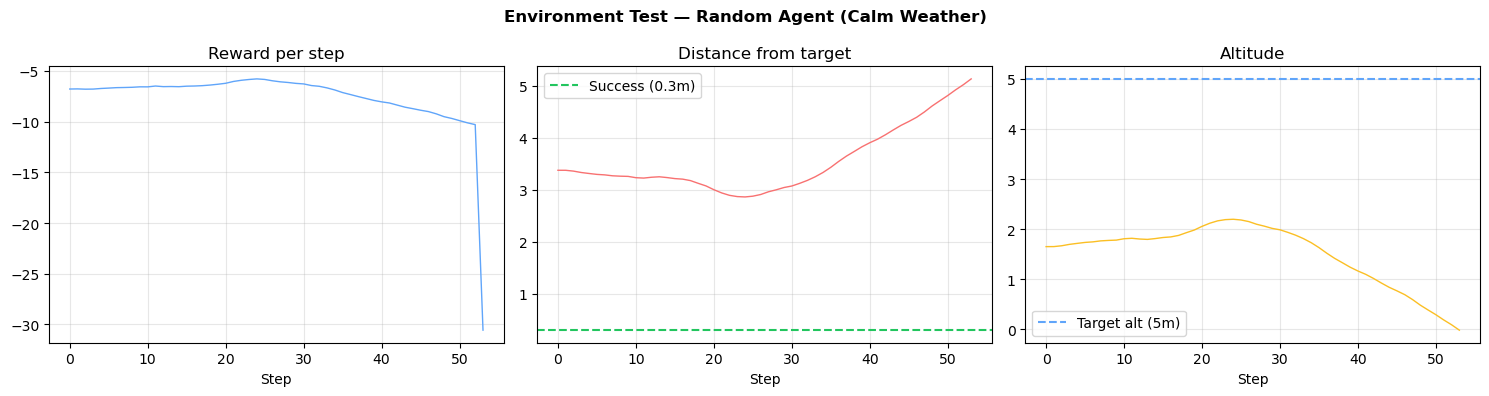

✅ Notebook 1 complete! Saved: results/nb1_env_test.png
➡️  Open Notebook 2 next.


In [4]:
# ── Test the environment ────────────────────────────────────
print("🧪 Testing environment with RANDOM actions...")
print("(Random drone will perform poorly — this is expected)")
print()

env = DroneWeatherEnv(difficulty=0)
obs, _ = env.reset()

rewards, distances, altitudes = [], [], []
done = False
total_reward = 0

while not done:
    action = env.action_space.sample()   # random action
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward
    rewards.append(reward)
    distances.append(info["distance"])
    altitudes.append(float(env.state[2]))

print(f"Episode length   : {len(rewards)} steps")
print(f"Total reward     : {total_reward:.2f}")
print(f"Final distance   : {distances[-1]:.2f} m from target")
print(f"Crashed          : {info['crashed']}")
print(f"Reached target   : {info['reached']}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Environment Test — Random Agent (Calm Weather)", fontweight="bold")

axes[0].plot(rewards, color="#60a5fa", lw=1)
axes[0].set_title("Reward per step"); axes[0].set_xlabel("Step")
axes[0].grid(True, alpha=0.3)

axes[1].plot(distances, color="#f87171", lw=1)
axes[1].axhline(0.3, color="#22c55e", linestyle="--", label="Success (0.3m)")
axes[1].set_title("Distance from target"); axes[1].set_xlabel("Step")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(altitudes, color="#fbbf24", lw=1)
axes[2].axhline(5.0, color="#60a5fa", linestyle="--", label="Target alt (5m)")
axes[2].set_title("Altitude"); axes[2].set_xlabel("Step")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/nb1_env_test.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Notebook 1 complete! Saved: results/nb1_env_test.png")
print("➡️  Open Notebook 2 next.")